In [3]:
from calendar import weekday
import datetime as dt
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels as sm
import sklearn
import math
from statsmodels.formula.api import ols
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from datetime import date, timedelta
import holidays

In [27]:
def plotShit(errors):

    plt.figure()
    sns.histplot(errors)
    plt.figure()
    sns.lineplot(errors)
    plot_acf(errors)
    plot_pacf(errors)

    return

def isWorkday(date):
    hol = holidays.FI()
    if date.weekday() in (5,6):
        return False
    elif date in hol:
        return False
    else:
        return True


In [3]:
#Dont run
df = pd.read_csv("Cleaned_data.csv")
df["TimeStamp"] = pd.to_datetime(df["TimeStamp"])
df["WeekDay"] = df["TimeStamp"].dt.day_name()
df["Date"] = df["TimeStamp"].apply(lambda x: x.date())
df["Weekend"] = df["WeekDay"]=="Sunday"
df.loc[df["WeekDay"]=="Saturday", "Weekend"]=True
df["Month"] = df["Date"].apply(lambda x: x.month)

In [4]:
#Dont run
# FURHAT MODEL

df_simple  =  df[["Electricity consumption in Finland", "Date", "Month", "WeekDay"]]
consumption  = df_simple.groupby("Date").aggregate({"Electricity consumption in Finland": "mean", "Date": "max", "WeekDay": "max", "Month": "max"})

consumption.reset_index(inplace=True, drop=True)
consumption["Trend"] = consumption.index
consumption["consumption"] = consumption["Electricity consumption in Finland"]*24
consumption.drop(["Date", "Electricity consumption in Finland"],axis=1, inplace=True)

model1 = ols(formula="consumption ~ Trend + C(Month) + C(WeekDay)", data=consumption)
res = model1.fit()
print(res.summary())
pred = {"WeekDay":"Monday", "Trend":927, "Month":3}
prediction = res.get_prediction(pred)


math.sqrt(prediction.var_pred_mean[0])

                            OLS Regression Results                            
Dep. Variable:            consumption   R-squared:                       0.847
Model:                            OLS   Adj. R-squared:                  0.844
Method:                 Least Squares   F-statistic:                     282.1
Date:                Wed, 18 Mar 2026   Prob (F-statistic):               0.00
Time:                        14:53:46   Log-Likelihood:                -10400.
No. Observations:                 937   AIC:                         2.084e+04
Df Residuals:                     918   BIC:                         2.093e+04
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                2

2405.117364344199

                            OLS Regression Results                            
Dep. Variable:            consumption   R-squared:                       0.846
Model:                            OLS   Adj. R-squared:                  0.844
Method:                 Least Squares   F-statistic:                     389.4
Date:                Wed, 18 Mar 2026   Prob (F-statistic):               0.00
Time:                        14:53:48   Log-Likelihood:                -10391.
No. Observations:                 936   AIC:                         2.081e+04
Df Residuals:                     922   BIC:                         2.088e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept              2.754e+

<Axes: ylabel='consumption'>

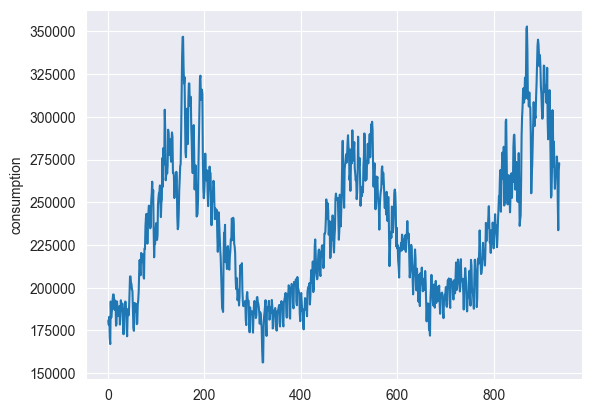

In [5]:
#Dont run

df2 = consumption.copy().iloc[1:,:]
workday = {
    "Saturday": "Weekend",
    "Sunday": "Weekend",
    "Monday" :"Workday",
    "Tuesday" : "Workday",
    "Wednesday":"Workday",
    "Thursday":"Workday",
    "Friday":"Workday"
}


df2["WeekDay"]=df2["WeekDay"].apply(lambda x: workday[x])

model2 = ols(formula="consumption ~ Trend + C(Month) + C(WeekDay)", data=df2)
res = model2.fit()
print(res.summary())

sns.lineplot(df2["consumption"])

In [6]:
#Dont run

df_temp = df.iloc[:,[1,4,7,10,12]]
df_daily = df_temp.groupby("Date").aggregate("mean")
df_daily["Consumption"] = df_daily["Electricity consumption in Finland"]*24
df_daily.drop(["Electricity consumption in Finland"],inplace=True, axis=1)
df_daily.rename(columns={"Mean Hel":"mean_hel","Mean Rov":"mean_rov","Mean Tam":"mean_tam" }, inplace=True)
df_daily["mean_temp"] = df_daily[["mean_hel","mean_rov","mean_tam"]].sum(axis=1)/3

df_norm = (df_daily-df_daily.min())/(df_daily.max()-df_daily.min())


model_temperature1 = ols(formula="Consumption ~ mean_hel + mean_rov + mean_tam", data=df_daily)
print(model_temperature1.fit().summary())
model_temperature2 = ols(formula="Consumption ~ mean_temp", data=df_daily)
print(model_temperature2.fit().summary())




df_daily.reset_index(inplace=True)

df_daily["workday"] = df_daily["Date"].apply(isWorkday)
df_daily

model_temperatureandworkday = ols(formula="Consumption ~ mean_temp + C(workday)", data=df_daily)

res = model_temperatureandworkday.fit()
errors =  df_daily["Consumption"]-res.predict()

df_daily

                            OLS Regression Results                            
Dep. Variable:            Consumption   R-squared:                       0.857
Model:                            OLS   Adj. R-squared:                  0.856
Method:                 Least Squares   F-statistic:                     1862.
Date:                Wed, 18 Mar 2026   Prob (F-statistic):               0.00
Time:                        14:53:54   Log-Likelihood:                -10368.
No. Observations:                 937   AIC:                         2.074e+04
Df Residuals:                     933   BIC:                         2.076e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   2.553e+05   1060.869    240.676      0.0

,Date,mean_hel,mean_rov,mean_tam,Consumption,mean_temp,workday
0,2023-08-01,17.222222,19.144444,16.988889,176558.666667,17.785185,True
1,2023-08-02,17.895833,19.333333,17.600000,180882.500000,18.276389,True
2,2023-08-03,17.313043,20.195652,17.747826,178327.826087,18.418841,True
3,2023-08-04,17.454167,18.708333,17.566667,183002.750000,17.909722,True
4,2023-08-05,18.825000,17.408333,17.916667,170706.000000,18.050000,False
...,...,...,...,...,...,...,...
932,2026-03-13,3.812500,2.537500,5.225000,273251.175000,3.858333,True
933,2026-03-14,6.175000,3.495833,6.083333,249763.465000,5.251389,False
934,2026-03-15,6.058333,0.941667,6.600000,233650.310000,4.533333,False
935,2026-03-16,1.808333,0.320833,2.250000,268520.075000,1.459722,True


Same day temperature explains 86% variance. Aggregated works just as well. let's see how off days affect.

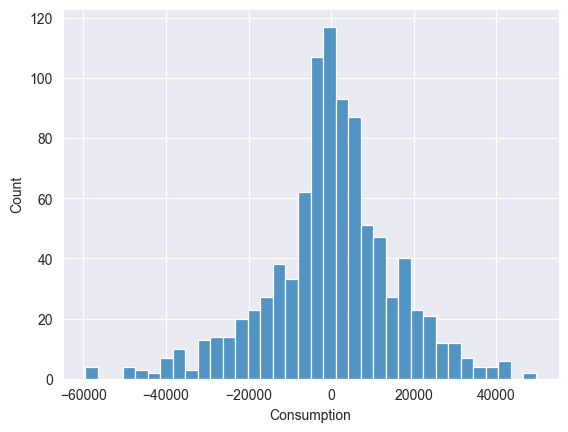

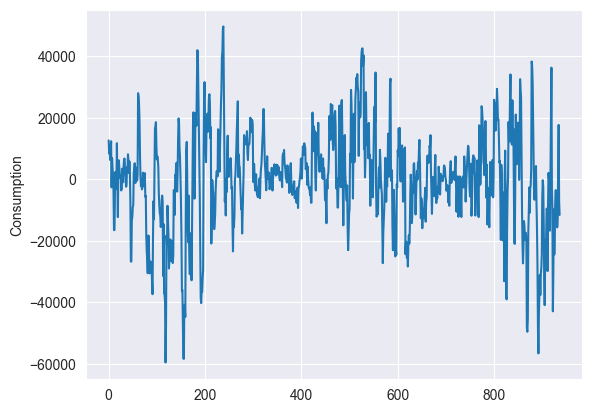

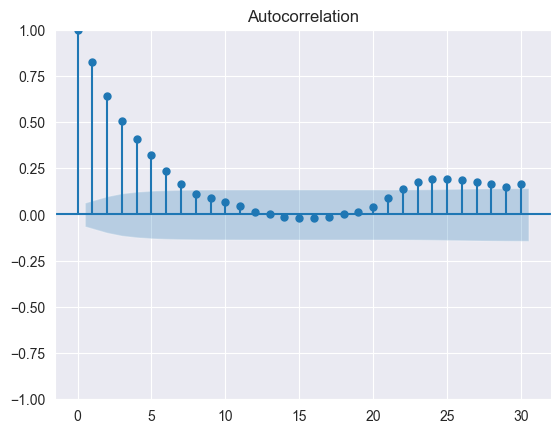

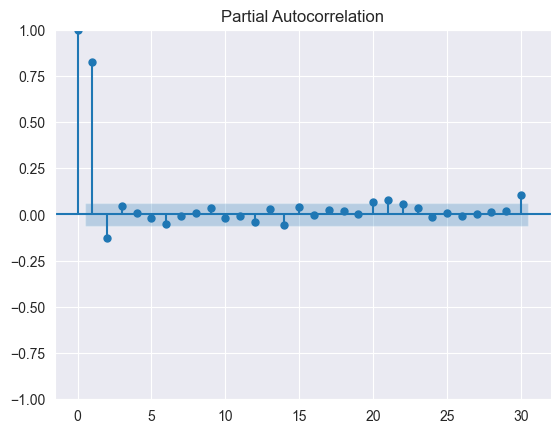

In [7]:
#Dont run

df_daily["month"] = df_daily["Date"].apply(lambda x: x.month)
df_daily["day"] = df_daily["Date"].apply(lambda x: x.weekday())
df_daily["year"] = df_daily["Date"].apply(lambda x: x.year)
df_daily["trend"] = df_daily.index

#sns.scatterplot(df_daily.groupby("day")["Consumption"].mean())
#plt.show()
#sns.scatterplot(df_daily.groupby("month")["Consumption"].mean())


datemodel = ols(formula="Consumption ~ C(month) + C(workday) + trend", data=df_daily)
errors = datemodel.fit().predict()-df_daily["Consumption"]

datemodel.fit().summary()
plotShit(errors)

<Axes: ylabel='log_consumption'>

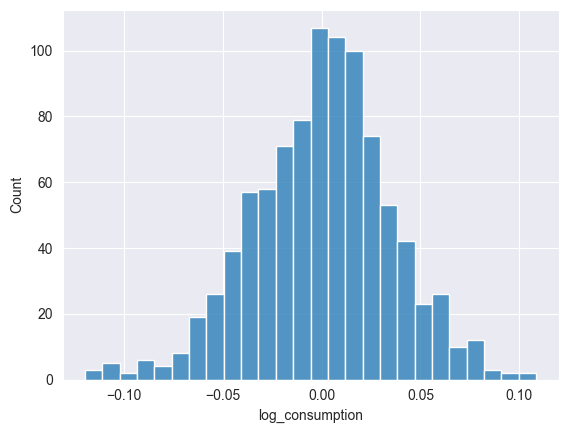

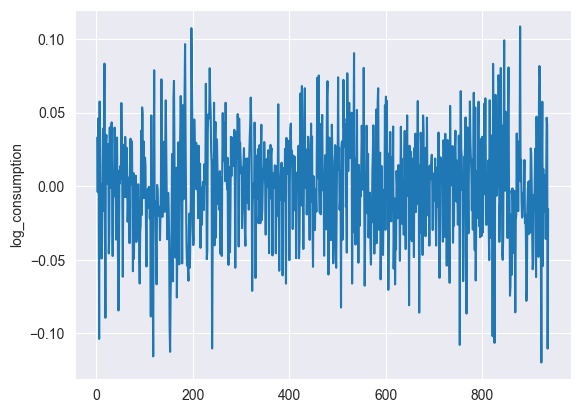

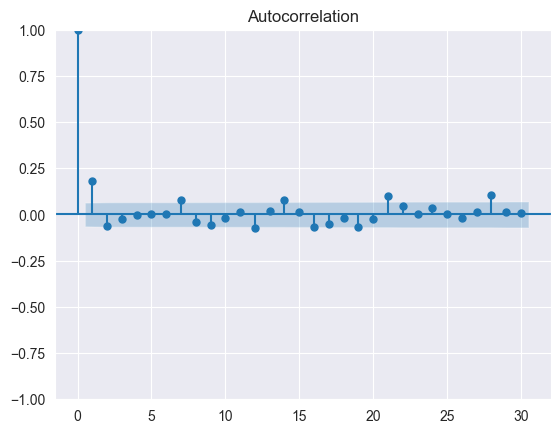

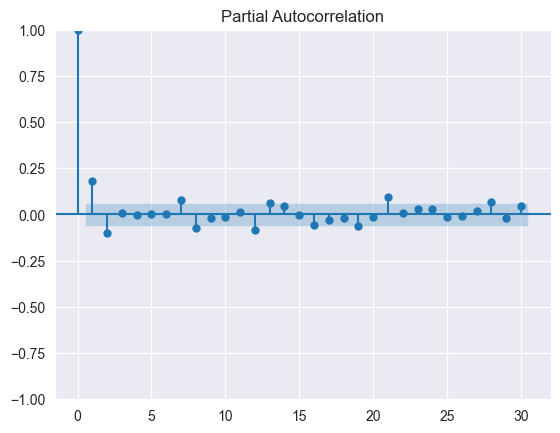

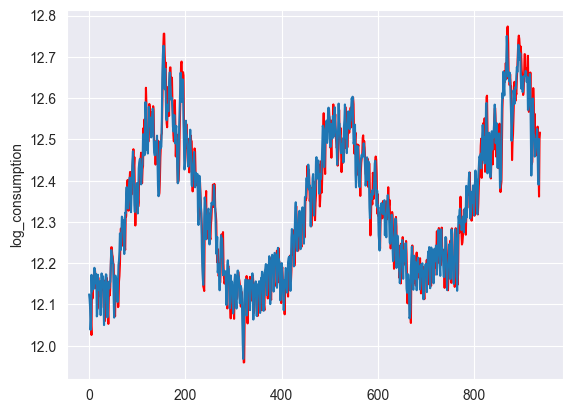

In [8]:
#Dont run

lags = sm.tsa.tsatools.lagmat(df_daily["Consumption"], maxlag=2)
df_daily.loc[:,"l1"] = lags[:,0]
df_daily.loc[:,"l2"] = lags[:,1]
df_daily["log_consumption"] = df_daily["Consumption"].apply(math.log)
lags_log = sm.tsa.tsatools.lagmat(df_daily["log_consumption"], maxlag=2)
df_daily.loc[:,"l1_log"] = lags_log[:,0]
df_daily.loc[:,"l2_log"] = lags_log[:,1]
#df_ar = df_daily
df_daily.to_csv("Dailydf.csv")
df_ar = df_daily[df_daily["l2"]!=0]
#arpredictlag = ols(formula="Consumption ~ C(month) + C(workday) + trend + l1", data=df_ar)
#lagged1 = arpredictlag.fit()
#df_ar.loc[:,["predictedl1"]] = lagged1.predict()




armodel = ols(formula="log_consumption ~ C(month) + C(workday) + trend + l1_log", data=df_ar)
res = armodel.fit()
errors = res.predict()-df_ar["log_consumption"]
plotShit(errors)
armodel.fit().summary()
##
plt.figure()
sns.lineplot(df_ar["log_consumption"],color="r")
sns.lineplot(res.predict())


# now case this shit in a function somehow

In [57]:





def fitModel(date,data, plotshit=True):

    df1 = data[data["Date"]<=date]



    df1 = df1[df1["l2"]!=0]

    m = ols(formula="log_consumption ~ C(month) + C(workday) + trend + l1_log", data=df1)
    r = m.fit()

    if plotshit:
        err = r.predict()-df1["log_consumption"]
        plotShit(err)
        ##
        plt.figure()
        sns.lineplot(df1["log_consumption"],color="r")
        sns.lineplot(r.predict())

    tplus1 = date+ timedelta(days=1)
    tplus2 = date+ timedelta(days=2)
    trend0 = max(df1["trend"])
    xt1 =  {"month" : tplus1.month,
           "workday" : isWorkday(tplus1),
           "trend" : trend0+1,
           "l1_log" : df1.iloc[-1,:]["l1_log"]}

    yt1 = r.predict(xt1)
    xt2 = {"month" : tplus2.month,
           "workday" : isWorkday(tplus2),
           "trend" : trend0+2,
           "l1_log" : yt1}
    yt2 = r.predict(xt2)

    return r, yt2




In [67]:
df1 = pd.read_csv("Dailydf.csv",parse_dates=["Date"])

df_spring = df1[df1["Date"]>=dt.datetime(2026,1,1)].set_index("Date").loc[:,["log_consumption","trend"]]
df_spring["predicted"] = pd.Series()

date = dt.datetime(2026,1,1)

while date<dt.datetime(2026,3,18):
    r,y = fitModel(date-dt.timedelta(days=2),df1, False)
    df_spring.loc[date, "predicted"] = y[0]
    date+=dt.timedelta(days=1)




0    12.551153
dtype: float64
2026-01-02 00:00:00
0    12.58805
dtype: float64
2026-01-03 00:00:00
0    12.594955
dtype: float64
2026-01-04 00:00:00
0    12.582662
dtype: float64
2026-01-05 00:00:00
0    12.62549
dtype: float64
2026-01-06 00:00:00
0    12.602637
dtype: float64
2026-01-07 00:00:00
0    12.620456
dtype: float64
2026-01-08 00:00:00
0    12.671721
dtype: float64
2026-01-09 00:00:00
0    12.649477
dtype: float64
2026-01-10 00:00:00
0    12.637702
dtype: float64
2026-01-11 00:00:00
0    12.660253
dtype: float64
2026-01-12 00:00:00
0    12.703114
dtype: float64
2026-01-13 00:00:00
0    12.707601
dtype: float64
2026-01-14 00:00:00
0    12.653715
dtype: float64
2026-01-15 00:00:00
0    12.659993
dtype: float64
2026-01-16 00:00:00
0    12.644236
dtype: float64
2026-01-17 00:00:00
0    12.620669
dtype: float64
2026-01-18 00:00:00
0    12.573679
dtype: float64
2026-01-19 00:00:00
0    12.610509
dtype: float64
2026-01-20 00:00:00
0    12.606717
dtype: float64
2026-01-21 00:00:00
0 

(<statsmodels.regression.linear_model.RegressionResultsWrapper at 0x20fc67f1d90>,
 0    12.501309
 dtype: float64)

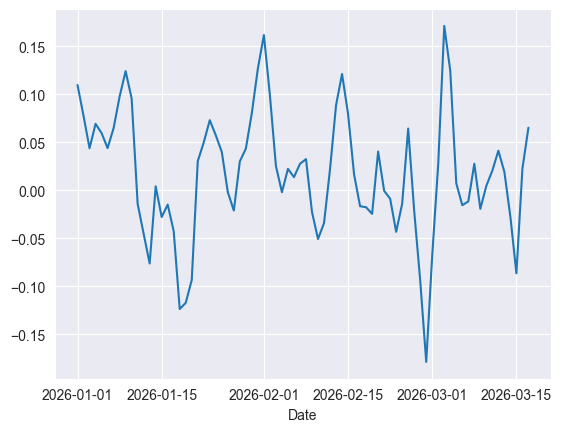

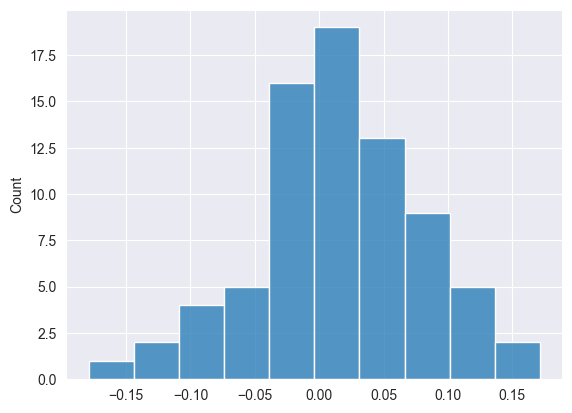

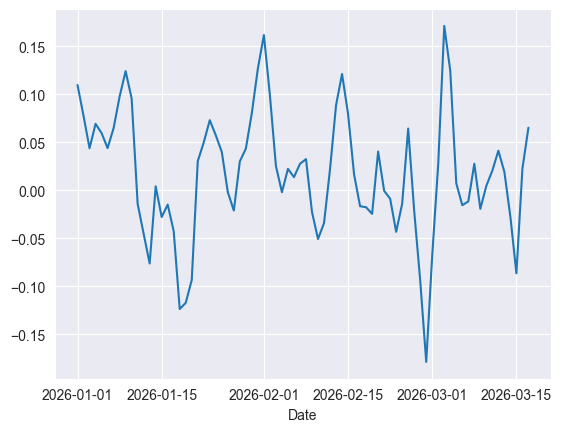

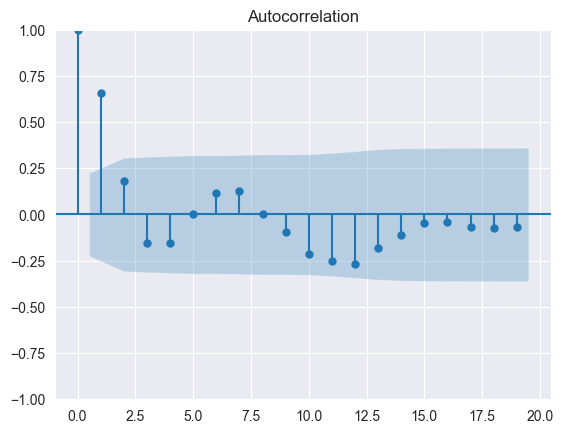

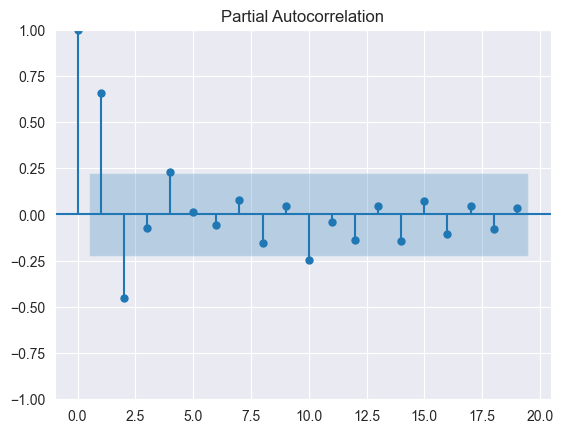

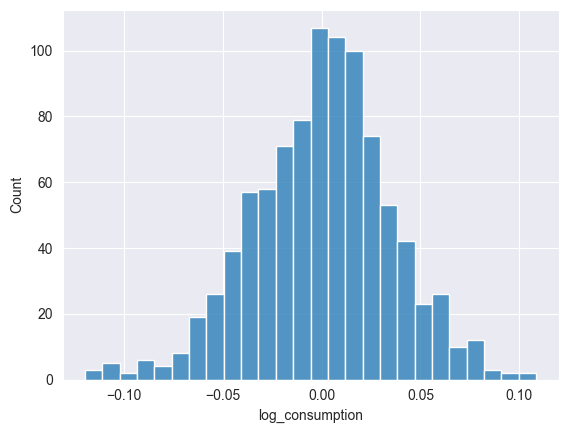

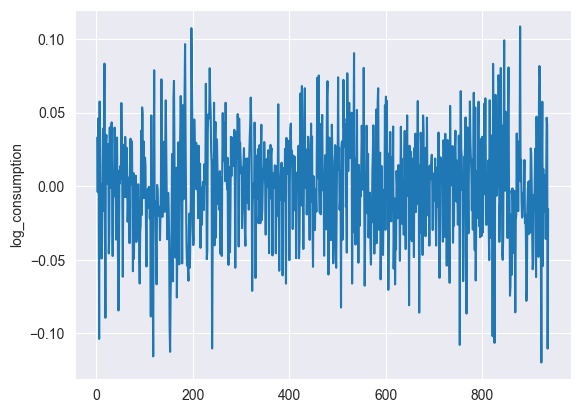

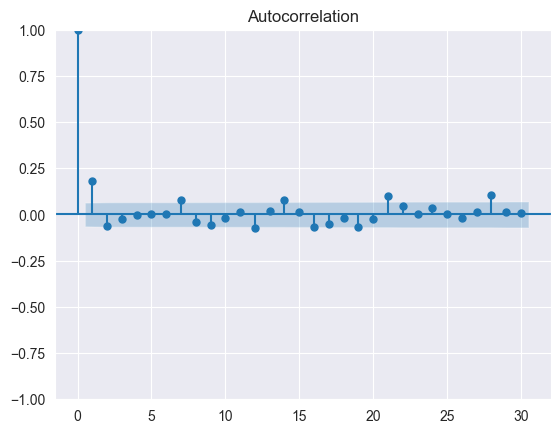

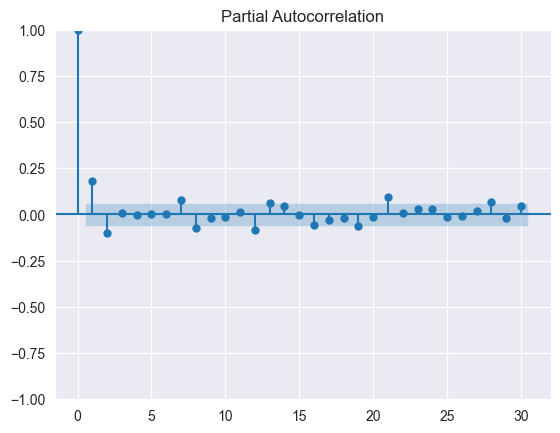

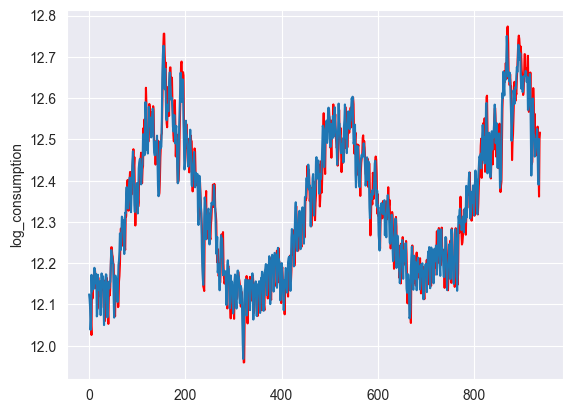

In [76]:
errors= df_spring["log_consumption"]-df_spring["predicted"]
sns.lineplot(errors)
plotShit(errors)
import statistics
statistics.stdev(errors)
#errors still autocorrelated

df_spring.loc[[dt.datetime(2026,3,9),dt.datetime(2026,3,12),dt.datetime(2026,3,15),dt.datetime(2026,3,9)]]

df_spring

fitModel(dt.datetime(2026,3,17),df1)
